# Fake Review Detection Using Isolation Forest

**Phase 2** of the pipeline: Identify and remove fake/suspicious Amazon app reviews before sentiment analysis.

## Methodology
1. **Load** pre-cleaned data from EDA phase (`reviews_clean_all.csv`)
2. **Rule-Based Detection** — 10 interpretable heuristic rules, each casts 1 vote
3. **Isolation Forest** — unsupervised anomaly detection model, casts 1 vote
4. **Ensemble Voting** — 11 voters total, 3 threshold levels
5. **Validation & Analysis** — agreement heatmap, PCA, feature importance
6. **Export** filtered dataset for Phase 3 sentiment analysis

### Why Isolation Forest?
- **Tree-based**: Isolates anomalies via random recursive partitioning — anomalies require fewer splits
- **Fast**: O(n log n) complexity, trains in seconds on 82K reviews
- **Interpretable**: Provides anomaly scores and feature importances

In [4]:
# --- Imports & Configuration ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


# Constants
RANDOM_SEED = 42
CONTAMINATION = 0.10
np.random.seed(RANDOM_SEED)

SAVE_DIR = '../Data/'
IMG_DIR  = '../Images/'

print('Libraries imported successfully')

Libraries imported successfully


## 1. Load EDA Output

Load the pre-cleaned dataset from Phase 1 (`reviews_clean_all.csv`). This contains 82,069 reviews with 26 pre-computed numeric features.

In [3]:
df = pd.read_csv(f'{SAVE_DIR}reviews_clean_all.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
print(f'\nScore distribution:')
print(df['score'].value_counts().sort_index())
print(f'\nFirst 3 rows:')
df.head(3)

Dataset shape: (82069, 32)
Columns (32): ['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'at', 'appVersion', 'year', 'month', 'day_of_week', 'hour', 'content_clean', 'is_anonymous_user', 'char_len', 'word_count', 'avg_word_len', 'exclamation_count', 'question_count', 'digit_count', 'has_url', 'caps_ratio', 'emoji_count', 'repeated_char_flag', 'is_duplicate_text', 'dup_text_weight', 'reviews_by_userName', 'is_very_short', 'unique_word_ratio', 'stopword_ratio', 'punctuation_ratio', 'score_extremity', 'vader_compound']

Score distribution:
1    37285
2     8642
3     6709
4     5334
5    24099
Name: score, dtype: int64

First 3 rows:


,reviewId,userName,content,score,thumbsUpCount,at,appVersion,year,month,day_of_week,...,repeated_char_flag,is_duplicate_text,dup_text_weight,reviews_by_userName,is_very_short,unique_word_ratio,stopword_ratio,punctuation_ratio,score_extremity,vader_compound
0,7e8c7234-99ea-4ad0-ac00-4d45b32ba2d0,A Google user,"It worked at first, but now I can't access the...",2,1,2018-09-12 10:08:56,16.17.0.100,2018,9,2,...,0,0,0.0,1,0,0.851852,0.518519,0.040323,1,0.0000
1,9ce95bd2-0c85-4982-a734-a0b50d9b5404,A Google user,I have the galaxy note 8 the app doesn't allow...,1,2,2018-09-12 13:15:00,16.17.0.100,2018,9,2,...,0,0,0.0,1,0,0.760870,0.608696,0.037383,2,-0.1695
2,4a76df7d-ad3a-4a37-81ac-407b2a1af1e0,A Google user,Can no longer log in to Amazon apps. Neither m...,1,9,2018-09-12 16:52:03,16.17.0.100,2018,9,2,...,1,0,0.0,1,0,0.783333,0.433333,0.029674,2,-0.1195


## 2. Feature Selection

Select 21 numeric features for Isolation Forest. Excluded:
- Text/ID columns (`content`, `content_clean`, `userName`, `reviewId`)
- `at` (datetime string), `appVersion` (categorical)
- `year`, `month` — temporal leakage risk
- `is_very_short` — redundant with `word_count <= 3` (Rule 1)
- `digit_count`, `repeated_char_flag` — low signal

In [12]:
ML_FEATURES = [
    'score',              # Rating manipulation signal
    'thumbsUpCount',      # Community trust signal
    'char_len',           # Review length
    'word_count',         # Review substance
    'avg_word_len',       # Vocabulary complexity
    'caps_ratio',         # Shouting/spam signal
    'exclamation_count',  # Emotional manipulation
    'question_count',     # Engagement pattern
    'emoji_count',        # Informal/spam signal
    'has_url',            # Spam/promotion signal
    'is_duplicate_text',  # Copy-paste reviews
    'dup_text_weight',    # Length-weighted duplicate signal
    'reviews_by_userName',# Prolific reviewer signal
    'is_anonymous_user',  # Anonymous reviewer flag
    'unique_word_ratio',  # Lexical diversity
    'stopword_ratio',     # Content substance
    'punctuation_ratio',  # Text quality signal
    'vader_compound',     # Sentiment polarity
    'hour',               # Time-of-day pattern
    'day_of_week',        # Day-of-week pattern
    'score_extremity',    # Distance from neutral
]

# Validate all features exist
missing = [f for f in ML_FEATURES if f not in df.columns]
if missing:
    raise ValueError(f'Missing features: {missing}')

print(f'Selected {len(ML_FEATURES)} features for Isolation Forest:')
for i, f in enumerate(ML_FEATURES, 1):
    print(f'  {i:2d}. {f}')

print(f'\nFeature statistics:')
df[ML_FEATURES].describe().round(3)

Selected 21 features for Isolation Forest:
   1. score
   2. thumbsUpCount
   3. char_len
   4. word_count
   5. avg_word_len
   6. caps_ratio
   7. exclamation_count
   8. question_count
   9. emoji_count
  10. has_url
  11. is_duplicate_text
  12. dup_text_weight
  13. reviews_by_userName
  14. is_anonymous_user
  15. unique_word_ratio
  16. stopword_ratio
  17. punctuation_ratio
  18. vader_compound
  19. hour
  20. day_of_week
  21. score_extremity

Feature statistics:


,score,thumbsUpCount,char_len,word_count,avg_word_len,caps_ratio,exclamation_count,question_count,emoji_count,has_url,...,dup_text_weight,reviews_by_userName,is_anonymous_user,unique_word_ratio,stopword_ratio,punctuation_ratio,vader_compound,hour,day_of_week,score_extremity
count,82069.000,82069.000,82069.000,82069.000,82069.000,82069.000,82069.000,82069.000,82069.000,82069.0,...,82069.00,82069.000,82069.000,82069.000,82069.000,82069.000,82069.000,82069.000,82069.000,82069.000
mean,2.638,8.978,183.415,34.054,5.450,0.048,0.411,0.122,0.084,0.0,...,0.01,1.372,0.095,0.891,0.404,0.028,0.117,10.502,2.992,1.666
std,1.741,69.057,144.619,27.051,1.113,0.091,1.857,0.573,0.567,0.0,...,0.05,2.119,0.293,0.098,0.155,0.028,0.565,7.023,1.993,0.621
min,1.000,0.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.0,...,0.00,1.000,0.000,0.143,0.000,0.000,-0.993,0.000,0.000,0.000
25%,1.000,0.000,74.000,13.000,5.000,0.018,0.000,0.000,0.000,0.0,...,0.00,1.000,0.000,0.818,0.353,0.014,-0.377,4.000,1.000,1.000
50%,2.000,0.000,143.000,27.000,5.370,0.030,0.000,0.000,0.000,0.0,...,0.00,1.000,0.000,0.903,0.443,0.025,0.122,11.000,3.000,2.000
75%,5.000,1.000,267.000,50.000,5.765,0.047,0.000,0.000,0.000,0.0,...,0.00,1.000,0.000,1.000,0.500,0.037,0.625,16.000,5.000,2.000
max,5.000,5660.000,1594.000,306.000,125.000,1.000,362.000,45.000,58.000,0.0,...,1.00,36.000,1.000,1.000,1.000,1.000,0.997,23.000,6.000,2.000


## 3. Rule-Based Detection (10 Rules)

Each rule is an independent binary voter targeting obvious patterns of fake/suspicious reviews.

In [11]:
# R1: Generic short + extreme rating
df['rule_1'] = ((df['word_count'] <= 3) & (df['score'].isin([1, 5]))).astype(int)

# R2: Extreme + no engagement + short
df['rule_2'] = ((df['score'].isin([1, 5])) & 
                (df['thumbsUpCount'] == 0) & 
                (df['word_count'] < 10)).astype(int)

# R3: Excessive caps (>50%, only for reviews >20 chars)
df['rule_3'] = ((df['caps_ratio'] > 0.5) & (df['char_len'] > 20)).astype(int)

# R4: Weighted duplicate text (substantial duplicates only)
df['rule_4'] = (df['dup_text_weight'] >= 0.5).astype(int)

# R5: Excessive exclamation marks
df['rule_5'] = (df['exclamation_count'] > 5).astype(int)

# R6: Many emojis
df['rule_6'] = (df['emoji_count'] > 3).astype(int)

# R7: VADER-score mismatch
df['rule_7'] = (((df['vader_compound'] > 0.5) & (df['score'] == 1)) | 
                ((df['vader_compound'] < -0.5) & (df['score'] == 5))).astype(int)

# R8: Low lexical diversity (only for reviews >10 words)
df['rule_8'] = ((df['unique_word_ratio'] < 0.4) & (df['word_count'] > 10)).astype(int)

# R9: Has URL (promotional/spam)
df['rule_9'] = (df['has_url'] == 1).astype(int)

# R10: Short anonymous + extreme rating
df['rule_10'] = ((df['is_anonymous_user'] == 1) & 
                 (df['word_count'] <= 5) & 
                 (df['score'].isin([1, 5]))).astype(int)

print('10 rules applied.')

10 rules applied.


Rule-Based Detection Fire Rates:
  R1: Generic short + extreme: 6,564 (8.00%)
  R2: Extreme + no thumbs + short: 13,192 (16.07%)
  R3: Excessive caps (>50%): 467 (0.57%)
  R4: Weighted duplicate text: 99 (0.12%)
  R5: Excessive exclamation (>5): 984 (1.20%)
  R6: Many emojis (>3): 132 (0.16%)
  R7: VADER-score mismatch: 5,171 (6.30%)
  R8: Low lexical diversity: 3 (0.00%)
  R9: Has URL: 0 (0.00%)
  R10: Short anonymous extreme: 10 (0.01%)

Reviews flagged by at least 1 rule: 19,646 (23.94%)


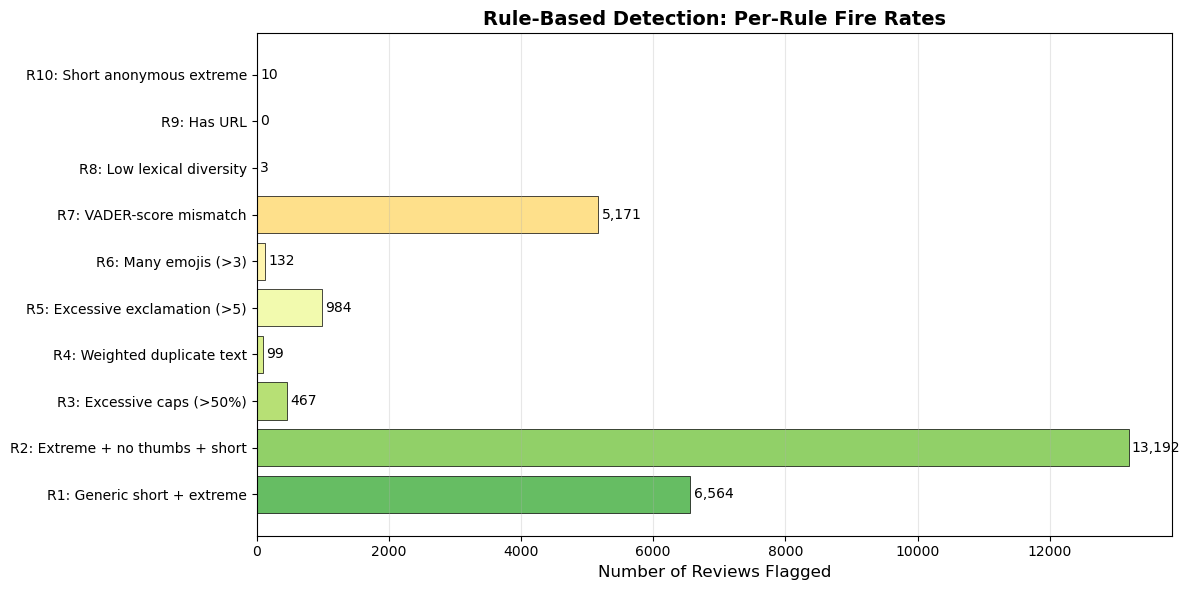

In [10]:
# Per-rule fire rates
rule_cols = [f'rule_{i}' for i in range(1, 11)]
rule_names = [
    'R1: Generic short + extreme',
    'R2: Extreme + no thumbs + short',
    'R3: Excessive caps (>50%)',
    'R4: Weighted duplicate text',
    'R5: Excessive exclamation (>5)',
    'R6: Many emojis (>3)',
    'R7: VADER-score mismatch',
    'R8: Low lexical diversity',
    'R9: Has URL',
    'R10: Short anonymous extreme',
]

print('Rule-Based Detection Fire Rates:')
print('=' * 60)
for col, name in zip(rule_cols, rule_names):
    count = df[col].sum()
    pct = count / len(df) * 100
    print(f'  {name}: {count:,} ({pct:.2f}%)')

df['rule_vote_count'] = df[rule_cols].sum(axis=1)
print(f'\nReviews flagged by at least 1 rule: {(df["rule_vote_count"] >= 1).sum():,} '
      f'({(df["rule_vote_count"] >= 1).mean()*100:.2f}%)')

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
fire_counts = [df[c].sum() for c in rule_cols]
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(rule_cols)))
bars = ax.barh(rule_names, fire_counts, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Reviews Flagged', fontsize=12)
ax.set_title('Rule-Based Detection: Per-Rule Fire Rates', fontsize=14, fontweight='bold')
for bar, count in zip(bars, fire_counts):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}rule_fire_rates.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Isolation Forest

Isolation Forest isolates anomalies by randomly selecting a feature and a split value. Anomalies are isolated in fewer splits (shorter path lengths), producing lower anomaly scores.

**Parameters:**
- `n_estimators=200` — number of isolation trees (increased from default 100 for stability)
- `max_samples='auto'` — uses min(256, n_samples) per tree
- `contamination=0.10` — expected proportion of anomalies

**Note:** No StandardScaler needed — Isolation Forest is tree-based and scale-invariant.

In [13]:
# Prepare feature matrix
X = df[ML_FEATURES].fillna(0).values

print(f'Training Isolation Forest on {X.shape[0]:,} samples with {X.shape[1]} features...')

iso_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=CONTAMINATION,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

iso_predictions = iso_forest.fit_predict(X)
iso_scores = iso_forest.score_samples(X)

# -1 = anomaly, 1 = normal -> convert to 0/1 (1 = anomaly)
df['iso_forest'] = (iso_predictions == -1).astype(int)
df['iso_forest_score'] = iso_scores

print(f'\nIsolation Forest complete:')
print(f'  Anomalies detected: {df["iso_forest"].sum():,} ({df["iso_forest"].mean()*100:.2f}%)')
print(f'  Normal reviews:     {(df["iso_forest"] == 0).sum():,}')
print(f'  Anomaly score range: [{iso_scores.min():.4f}, {iso_scores.max():.4f}]')

Training Isolation Forest on 82,069 samples with 21 features...

Isolation Forest complete:
  Anomalies detected: 8,207 (10.00%)
  Normal reviews:     73,862
  Anomaly score range: [-0.6787, -0.3582]


## 5. Contamination Sensitivity Analysis

Test how the number of detected anomalies changes with different contamination rates (0.05, 0.10, 0.15). This justifies the choice of `contamination=0.10`.

Contamination=0.05: 4,104 anomalies (5.00%)
Contamination=0.10: 8,207 anomalies (10.00%)
Contamination=0.15: 12,311 anomalies (15.00%)

Sensitivity Analysis:
 Contamination  Anomalies Percentage
          0.05       4104      5.00%
          0.10       8207     10.00%
          0.15      12311     15.00%


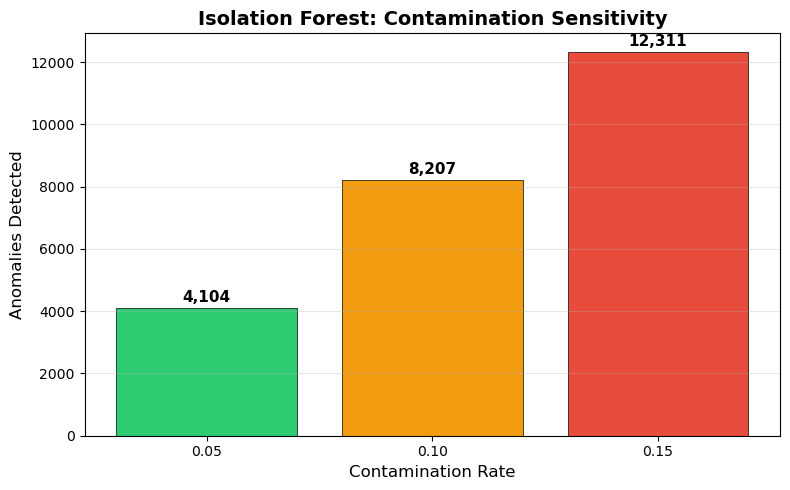


Selected contamination=0.10 as a balanced choice between precision and coverage.


In [14]:
contamination_levels = [0.05, 0.10, 0.15]
sensitivity_results = []

for c in contamination_levels:
    model = IsolationForest(n_estimators=200, max_samples='auto',
                            contamination=c, random_state=RANDOM_SEED, n_jobs=-1)
    preds = model.fit_predict(X)
    count = (preds == -1).sum()
    sensitivity_results.append({
        'Contamination': c,
        'Anomalies': count,
        'Percentage': f'{count/len(df)*100:.2f}%'
    })
    print(f'Contamination={c:.2f}: {count:,} anomalies ({count/len(df)*100:.2f}%)')

print(f'\nSensitivity Analysis:')
print(pd.DataFrame(sensitivity_results).to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
counts = [r['Anomalies'] for r in sensitivity_results]
bar_colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar([f'{c:.2f}' for c in contamination_levels], counts,
              color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Contamination Rate', fontsize=12)
ax.set_ylabel('Anomalies Detected', fontsize=12)
ax.set_title('Isolation Forest: Contamination Sensitivity', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}contamination_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nSelected contamination=0.10 as a balanced choice between precision and coverage.')

## 6. Ensemble Voting

Combine all 11 voters (10 rules + Isolation Forest). Each voter casts a binary vote (0 or 1). Total votes range from 0 to 11.

In [15]:
# All voter columns
all_voter_cols = rule_cols + ['iso_forest']

# Total vote count (0 to 11)
df['vote_count'] = df[all_voter_cols].sum(axis=1)

# Three threshold levels
df['is_fake_conservative'] = (df['vote_count'] >= 4).astype(int)
df['is_fake_moderate'] = (df['vote_count'] >= 3).astype(int)
df['is_fake_aggressive'] = (df['vote_count'] >= 2).astype(int)

print('Ensemble Detection Results (11 voters: 10 rules + Isolation Forest):')
print('=' * 65)
print(f'Conservative (>=4 votes): {df["is_fake_conservative"].sum():,} '
      f'({df["is_fake_conservative"].mean()*100:.2f}%)')
print(f'Moderate     (>=3 votes): {df["is_fake_moderate"].sum():,} '
      f'({df["is_fake_moderate"].mean()*100:.2f}%)')
print(f'Aggressive   (>=2 votes): {df["is_fake_aggressive"].sum():,} '
      f'({df["is_fake_aggressive"].mean()*100:.2f}%)')

print(f'\nVote distribution:')
print(df['vote_count'].value_counts().sort_index())

Ensemble Detection Results (11 voters: 10 rules + Isolation Forest):
Conservative (>=4 votes): 50 (0.06%)
Moderate     (>=3 votes): 2,873 (3.50%)
Aggressive   (>=2 votes): 8,218 (10.01%)

Vote distribution:
0    58383
1    15468
2     5345
3     2823
4       48
5        2
Name: vote_count, dtype: int64


## 7. Validation & Analysis

Assess detection quality through:
1. Inter-method agreement heatmap
2. Isolation Forest anomaly score distribution
3. Fake vs real characteristics comparison

In [16]:
# --- Save Output Files ---

# 1. Full dataset with all detection flags
df.to_csv(f'{SAVE_DIR}reviews_with_fake_detection.csv', index=False, encoding='utf-8-sig')
print(f'Saved: reviews_with_fake_detection.csv ({df.shape[0]:,} rows, {df.shape[1]} cols)')

# 2. Detected fake reviews only (moderate threshold)
df_fake = df[df['is_fake_moderate'] == 1].copy()
df_fake.to_csv(f'{SAVE_DIR}fake_reviews_detected.csv', index=False, encoding='utf-8-sig')
print(f'Saved: fake_reviews_detected.csv ({len(df_fake):,} rows)')

# 3. Clean dataset for sentiment analysis (fake reviews removed)
df_clean = df[df['is_fake_moderate'] == 0].copy()
df_clean.to_csv(f'{SAVE_DIR}reviews_clean_for_sentiment.csv', index=False, encoding='utf-8-sig')
print(f'Saved: reviews_clean_for_sentiment.csv ({len(df_clean):,} rows)')

# Verify downstream contract
assert 'score' in df_clean.columns, 'Missing score column!'
assert 'content_clean' in df_clean.columns, 'Missing content_clean column!'
print(f'\nDownstream contract verified: score and content_clean present')

# --- Summary ---
print(f'\n{"=" * 65}')
print(f'FAKE REVIEW DETECTION SUMMARY (Isolation Forest)')
print(f'{"=" * 65}')
print(f'\nInput: reviews_clean_all.csv ({len(df):,} reviews)')
print(f'\nDetection Methods:')
print(f'  Rule-based (10 rules): {(df["rule_vote_count"] >= 1).sum():,} flagged by at least 1 rule')
print(f'  Isolation Forest:      {df["iso_forest"].sum():,} anomalies ({df["iso_forest"].mean()*100:.2f}%)')
print(f'\nEnsemble Results (11 voters = 10 rules + 1 IF):')
print(f'  Conservative (>=4): {df["is_fake_conservative"].sum():,} ({df["is_fake_conservative"].mean()*100:.2f}%)')
print(f'  Moderate     (>=3): {df["is_fake_moderate"].sum():,} ({df["is_fake_moderate"].mean()*100:.2f}%)')
print(f'  Aggressive   (>=2): {df["is_fake_aggressive"].sum():,} ({df["is_fake_aggressive"].mean()*100:.2f}%)')
print(f'\nOutput Files:')
print(f'  reviews_with_fake_detection.csv  ({len(df):,} rows)')
print(f'  fake_reviews_detected.csv        ({len(df_fake):,} rows)')
print(f'  reviews_clean_for_sentiment.csv   ({len(df_clean):,} rows)')
print(f'\nScore distribution in clean dataset:')
for s in range(1, 6):
    c = (df_clean['score'] == s).sum()
    print(f'  {s} stars: {c:,} ({c/len(df_clean)*100:.1f}%)')

Saved: reviews_with_fake_detection.csv (82,069 rows, 49 cols)
Saved: fake_reviews_detected.csv (2,873 rows)
Saved: reviews_clean_for_sentiment.csv (79,196 rows)

Downstream contract verified: score and content_clean present

FAKE REVIEW DETECTION SUMMARY (Isolation Forest)

Input: reviews_clean_all.csv (82,069 reviews)

Detection Methods:
  Rule-based (10 rules): 19,646 flagged by at least 1 rule
  Isolation Forest:      8,207 anomalies (10.00%)

Ensemble Results (11 voters = 10 rules + 1 IF):
  Conservative (>=4): 50 (0.06%)
  Moderate     (>=3): 2,873 (3.50%)
  Aggressive   (>=2): 8,218 (10.01%)

Output Files:
  reviews_with_fake_detection.csv  (82,069 rows)
  fake_reviews_detected.csv        (2,873 rows)
  reviews_clean_for_sentiment.csv   (79,196 rows)

Score distribution in clean dataset:
  1 stars: 36,743 (46.4%)
  2 stars: 8,637 (10.9%)
  3 stars: 6,707 (8.5%)
  4 stars: 5,332 (6.7%)
  5 stars: 21,777 (27.5%)
